In [ ]:
#!pip install albumentations --upgrade -q

In [2]:
import os, math, random, shutil, json
import cv2
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
import albumentations as alb
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalMaxPooling2D, Dropout
from tensorflow.keras.applications import VGG16

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

2026-06-06 06:04:56.856450: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780725897.091833      91 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780725897.148899      91 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780725897.658806      91 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780725897.658854      91 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780725897.658857      91 computation_placer.cc:177] computation placer alr

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
DATASET_NAME   = 'datasets/suryach2/cleandata/data'   # ← change this
RAW_IMAGES_DIR = f'/kaggle/input/{DATASET_NAME}/images'
RAW_LABELS_DIR = f'/kaggle/input/{DATASET_NAME}/labels'
WORK_DIR       = '/kaggle/working'

print("Images:", len([f for f in os.listdir(RAW_IMAGES_DIR) if f.endswith('.jpg')]))
print("Labels:", len([f for f in os.listdir(RAW_LABELS_DIR) if f.endswith('.json')]))

Images: 145
Labels: 123


In [4]:
def split_dataset(train_r=0.70, val_r=0.10, seed=42):
    all_images = [f for f in os.listdir(RAW_IMAGES_DIR) if f.lower().endswith('.jpg')]
    random.seed(seed)
    random.shuffle(all_images)
    n       = len(all_images)
    n_train = math.floor(n * train_r)
    n_val   = math.floor(n * val_r)
    splits  = {
        'train': all_images[:n_train],
        'val':   all_images[n_train : n_train + n_val],
        'test':  all_images[n_train + n_val:]
    }
    for partition, files in splits.items():
        img_dir = os.path.join(WORK_DIR, 'data', partition, 'images')
        lbl_dir = os.path.join(WORK_DIR, 'data', partition, 'labels')
        os.makedirs(img_dir, exist_ok=True)
        os.makedirs(lbl_dir, exist_ok=True)
        for fname in files:
            shutil.copy2(os.path.join(RAW_IMAGES_DIR, fname), os.path.join(img_dir, fname))
            lbl = fname.rsplit('.', 1)[0] + '.json'
            src = os.path.join(RAW_LABELS_DIR, lbl)
            if os.path.exists(src):
                shutil.copy2(src, os.path.join(lbl_dir, lbl))
        print(f"  {partition:5s}: {len(files)}")

split_dataset()

  train: 101
  val  : 14
  test : 30


In [5]:
augmentor = alb.Compose([
    alb.RandomCrop(width=450, height=450),
    alb.HorizontalFlip(p=0.5),
    alb.RandomBrightnessContrast(p=0.3),
    alb.RandomGamma(p=0.3),
    alb.RGBShift(p=0.3),
    alb.HueSaturationValue(p=0.2),
    alb.GaussNoise(p=0.2),
    alb.Rotate(limit=15, p=0.3)
],
bbox_params=alb.BboxParams(format='albumentations', label_fields=['class_labels']))

def fix_coords(coords):
    x1, y1, x2, y2 = coords
    x_min, x_max = min(x1,x2), max(x1,x2)
    y_min, y_max = min(y1,y2), max(y1,y2)
    x_min = max(0.0, min(x_min, 1.0))
    y_min = max(0.0, min(y_min, 1.0))
    x_max = max(0.0, min(x_max, 1.0))
    y_max = max(0.0, min(y_max, 1.0))
    if x_max <= x_min: x_max = min(x_min + 0.001, 1.0)
    if y_max <= y_min: y_max = min(y_min + 0.001, 1.0)
    return [x_min, y_min, x_max, y_max]

for partition in ['train', 'val', 'test']:
    in_img  = os.path.join(WORK_DIR, 'data',     partition, 'images')
    in_lbl  = os.path.join(WORK_DIR, 'data',     partition, 'labels')
    out_img = os.path.join(WORK_DIR, 'aug_data', partition, 'images')
    out_lbl = os.path.join(WORK_DIR, 'aug_data', partition, 'labels')
    os.makedirs(out_img, exist_ok=True)
    os.makedirs(out_lbl, exist_ok=True)

    files = [f for f in os.listdir(in_img) if f.lower().endswith('.jpg')]
    print(f"Augmenting {partition} ({len(files)} images) ...")

    for image_file in files:
        img = cv2.imread(os.path.join(in_img, image_file))
        if img is None: continue

        coords    = [0.0, 0.0, 0.001, 0.001]
        lbl_path  = os.path.join(in_lbl, image_file.rsplit('.', 1)[0] + '.json')
        has_label = os.path.exists(lbl_path)

        if has_label:
            with open(lbl_path) as f:
                label = json.load(f)
            raw    = [label['shapes'][0]['points'][0][0],
                      label['shapes'][0]['points'][0][1],
                      label['shapes'][0]['points'][1][0],
                      label['shapes'][0]['points'][1][1]]
            coords = fix_coords(list(np.divide(raw, [640,480,640,480])))

        try:
            for x in range(100):
                aug      = augmentor(image=img, bboxes=[coords], class_labels=['face'])
                out_name = f"{image_file.rsplit('.', 1)[0]}.{x}"
                cv2.imwrite(os.path.join(out_img, out_name + '.jpg'), aug['image'])
                ann = {'image': image_file}
                if has_label:
                    ann['bbox']  = list(aug['bboxes'][0]) if aug['bboxes'] else [0,0,0,0]
                    ann['class'] = 1 if aug['bboxes'] else 0
                else:
                    ann['bbox']  = [0,0,0,0]
                    ann['class'] = 0
                with open(os.path.join(out_lbl, out_name + '.json'), 'w') as f:
                    json.dump(ann, f)
        except Exception as e:
            print(f"  [ERROR] {image_file}: {e}")

    print(f"  {partition} done -> {len(os.listdir(out_img))} augmented")

Augmenting train (101 images) ...
  train done -> 10100 augmented
Augmenting val (14 images) ...
  val done -> 1400 augmented
Augmenting test (30 images) ...
  test done -> 3000 augmented


In [6]:
def load_sample(image_path):
    # Load image
    img = tf.io.read_file(image_path)
    img = tf.cast(tf.io.decode_jpeg(img), tf.float32) / 255.0
    img = tf.image.resize(img, (120, 120))

    # Load label from same path
    lbl_path = tf.strings.regex_replace(image_path, 'images', 'labels')
    lbl_path = tf.strings.regex_replace(lbl_path,   '.jpg',   '.json')

    def _load(path):
        with open(path.numpy().decode()) as f:
            d = json.load(f)
        return np.array([float(d.get('class',0))] + list(d.get('bbox',[0,0,0,0])),
                        dtype=np.float32)

    label = tf.py_function(_load, [lbl_path], tf.float32)
    label.set_shape([5])
    return img, label

def make_dataset(partition, shuffle=False):
    paths = tf.data.Dataset.list_files(
        os.path.join(WORK_DIR, 'aug_data', partition, 'images', '*.jpg'),
        shuffle=shuffle)
    return paths.map(load_sample, num_parallel_calls=1)  # ← num_parallel_calls=1 keeps order

train_ds = make_dataset('train', shuffle=True)
val_ds   = make_dataset('val')
test_ds  = make_dataset('test')

print("Train:", train_ds.cardinality().numpy())
print("Val  :", val_ds.cardinality().numpy())
print("Test :", test_ds.cardinality().numpy())

I0000 00:00:1780726016.254490      91 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Train: 10100
Val  : 1400
Test : 3000


In [7]:
def build_model():
    inp = Input(shape=(120,120,3))
    vgg = VGG16(include_top=False)
    vgg.trainable = False              # freeze VGG16
    x   = vgg(inp, training=False)
    f   = GlobalMaxPooling2D()(x)
    # Classification head
    c   = Dropout(0.3)(f)
    c   = Dense(2048, activation='relu')(c)
    c   = Dense(1,    activation='sigmoid')(c)
    # Regression head
    r   = Dropout(0.3)(f)
    r   = Dense(2048, activation='relu')(r)
    r   = Dense(4,    activation='sigmoid')(r)
    return Model(inputs=inp, outputs=[c, r])

facetracker = build_model()
facetracker.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 120, 120,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 3, 3, 512) │ 14,714,688 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2048)      │  1,050,624 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 2048)      │  1,050,624 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │      2,049 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │      8,196 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,826,181 (64.19 MB)

 Trainable params: 2,111,493 (8.05 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [8]:
def localization_loss(y_true, y_pred):
    y_true = tf.reshape(y_true, (-1,4))
    y_pred = tf.reshape(y_pred, (-1,4))
    delta_coord = tf.reduce_sum(tf.square(y_true[:,:2] - y_pred[:,:2]))
    delta_size  = tf.reduce_sum(
        tf.square((y_true[:,2]-y_true[:,0]) - (y_pred[:,2]-y_pred[:,0])) +
        tf.square((y_true[:,3]-y_true[:,1]) - (y_pred[:,3]-y_pred[:,1])))
    return delta_coord + delta_size

class FaceTracker(Model):
    def __init__(self, model, **kwargs):
        super().__init__(**kwargs)
        self.model = model

    def get_config(self):
        return {}

    def compile(self, opt, classloss, locloss, **kwargs):
        super().compile(**kwargs)
        self.opt   = opt
        self.closs = classloss
        self.lloss = locloss

    def train_step(self, batch, **kwargs):
        X, y = batch
        with tf.GradientTape() as tape:
            cls, coords = self.model(X, training=True)
            closs = self.closs(y[:,0:1], cls)
            lloss = self.lloss(tf.cast(y[:,1:5], tf.float32), coords)
            loss  = lloss + 0.5*closs
            grads = tape.gradient(loss, self.model.trainable_variables)
        self.opt.apply_gradients(zip(grads, self.model.trainable_variables))
        return {"total_loss": loss, "class_loss": closs, "regress_loss": lloss}

    def test_step(self, batch, **kwargs):
        X, y = batch
        cls, coords = self.model(X, training=False)
        closs = self.closs(y[:,0:1], cls)
        lloss = self.lloss(tf.cast(y[:,1:5], tf.float32), coords)
        loss  = lloss + 0.5*closs
        return {"total_loss": loss, "class_loss": closs, "regress_loss": lloss}

    def call(self, X, **kwargs):
        return self.model(X, **kwargs)

print("FaceTracker defined.")

FaceTracker defined.


In [9]:
EPOCHS = 50
BATCH  = 8

opt   = tf.keras.optimizers.Adam(learning_rate=0.0001)
model = FaceTracker(facetracker)
model.compile(opt, tf.keras.losses.BinaryCrossentropy(), localization_loss)

best_val_loss = [float('inf')]

class SaveBestInner(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get('val_total_loss', float('inf'))
        if val_loss < best_val_loss[0]:
            best_val_loss[0] = val_loss
            facetracker.save(os.path.join(WORK_DIR, 'best_facetracker.h5'))
            print(f"  Epoch {epoch+1}: saved best (val_loss={val_loss:.4f})")

hist = model.fit(
    train_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE),
    epochs=EPOCHS,
    validation_data=val_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_total_loss', patience=7,
            restore_best_weights=True, mode='min', verbose=1),
        SaveBestInner()
    ]
)

Epoch 1/50


I0000 00:00:1780726020.918018     141 service.cc:152] XLA service 0x7ea9b8021010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780726020.918055     141 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780726021.576205     141 cuda_dnn.cc:529] Loaded cuDNN version 91002


   9/1263 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - class_loss: 0.4820 - regress_loss: 1.4828 - total_loss: 1.7238

I0000 00:00:1780726025.294953     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1263/1263 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - class_loss: 0.1311 - regress_loss: 0.6008 - total_loss: 0.6664

...

  Epoch 11: saved best (val_loss=0.4674)
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - class_loss: 0.1884 - regress_loss: 0.2154 - total_loss: 0.3096 - val_class_loss: 0.1038 - val_regress_loss: 0.4155 - val_total_loss: 0.4674
Epoch 12/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - class_loss: 0.3539 - regress_loss: 0.2152 - total_loss: 0.3921 - val_class_loss: 0.0893 - val_regress_loss: 0.4630 - val_total_loss: 0.5077
Epoch 13/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - class_loss: 2.6500e-04 - regress_loss: 0.0354 - total_loss: 0.0355 - val_class_loss: 0.1126 - val_regress_loss: 0.5362 - val_total_loss: 0.5925
Epoch 14/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - class_loss: 0.0173 - regress_loss: 0.1125 - total_loss: 0.1212 - val_class_loss: 0.0971 - val_regress_loss: 0.4511 - val_total_loss: 0.4997
Epoch 15/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - class_loss: 5.8838e-05 - regress_loss: 0.0286 - total_loss: 0.0286 - val_class_loss: 0.0360 - val_regress_loss: 

  Epoch 16: saved best (val_loss=0.4022)
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - class_loss: 2.8880e-04 - regress_loss: 0.0131 - total_loss: 0.0132 - val_class_loss: 0.0273 - val_regress_loss: 0.3885 - val_total_loss: 0.4022
Epoch 17/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - class_loss: 3.9959e-05 - regress_loss: 0.0585 - total_loss: 0.0585 - val_class_loss: 0.0411 - val_regress_loss: 0.3915 - val_total_loss: 0.4121
Epoch 18/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - class_loss: 0.0029 - regress_loss: 0.0718 - total_loss: 0.0732 - val_class_loss: 0.0360 - val_regress_loss: 0.4285 - val_total_loss: 0.4464
Epoch 19/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - class_loss: 0.0156 - regress_loss: 0.2060 - total_loss: 0.2138 - val_class_loss: 0.0870 - val_regress_loss: 0.4136 - val_total_loss: 0.4571
Epoch 20/50
1262/1263 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - class_loss: 0.0299 - regress_loss: 0.1526 - total_loss: 0.1675

  Epoch 20: saved best (val_loss=0.3775)
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - class_loss: 6.0352e-04 - regress_loss: 0.0137 - total_loss: 0.0140 - val_class_loss: 0.0300 - val_regress_loss: 0.3625 - val_total_loss: 0.3775
Epoch 21/50
1261/1263 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - class_loss: 0.0277 - regress_loss: 0.1519 - total_loss: 0.1657

  Epoch 21: saved best (val_loss=0.3442)
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - class_loss: 1.1204e-04 - regress_loss: 0.0250 - total_loss: 0.0250 - val_class_loss: 0.0052 - val_regress_loss: 0.3416 - val_total_loss: 0.3442
Epoch 22/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - class_loss: 0.0064 - regress_loss: 0.0232 - total_loss: 0.0264 - val_class_loss: 0.0159 - val_regress_loss: 0.3437 - val_total_loss: 0.3517
Epoch 23/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - class_loss: 0.0052 - regress_loss: 0.1563 - total_loss: 0.1588 - val_class_loss: 0.0291 - val_regress_loss: 0.3415 - val_total_loss: 0.3561
Epoch 24/50
1262/1263 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - class_loss: 0.0244 - regress_loss: 0.1381 - total_loss: 0.1503

  Epoch 24: saved best (val_loss=0.2871)
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - class_loss: 9.2101e-04 - regress_loss: 0.0076 - total_loss: 0.0080 - val_class_loss: 0.0469 - val_regress_loss: 0.2636 - val_total_loss: 0.2871
Epoch 25/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - class_loss: 0.0057 - regress_loss: 0.0172 - total_loss: 0.0201 - val_class_loss: 0.0584 - val_regress_loss: 0.3389 - val_total_loss: 0.3680
Epoch 26/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - class_loss: 0.0610 - regress_loss: 0.2692 - total_loss: 0.2997 - val_class_loss: 0.0390 - val_regress_loss: 0.3958 - val_total_loss: 0.4154
Epoch 27/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - class_loss: 0.0286 - regress_loss: 0.1239 - total_loss: 0.1383 - val_class_loss: 0.0129 - val_regress_loss: 0.4300 - val_total_loss: 0.4364
Epoch 28/50
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - class_loss: 1.0499e-04 - regress_loss: 0.0639 - total_loss: 0.0639 - val_class_loss: 0.0186 - val_regress_loss: 

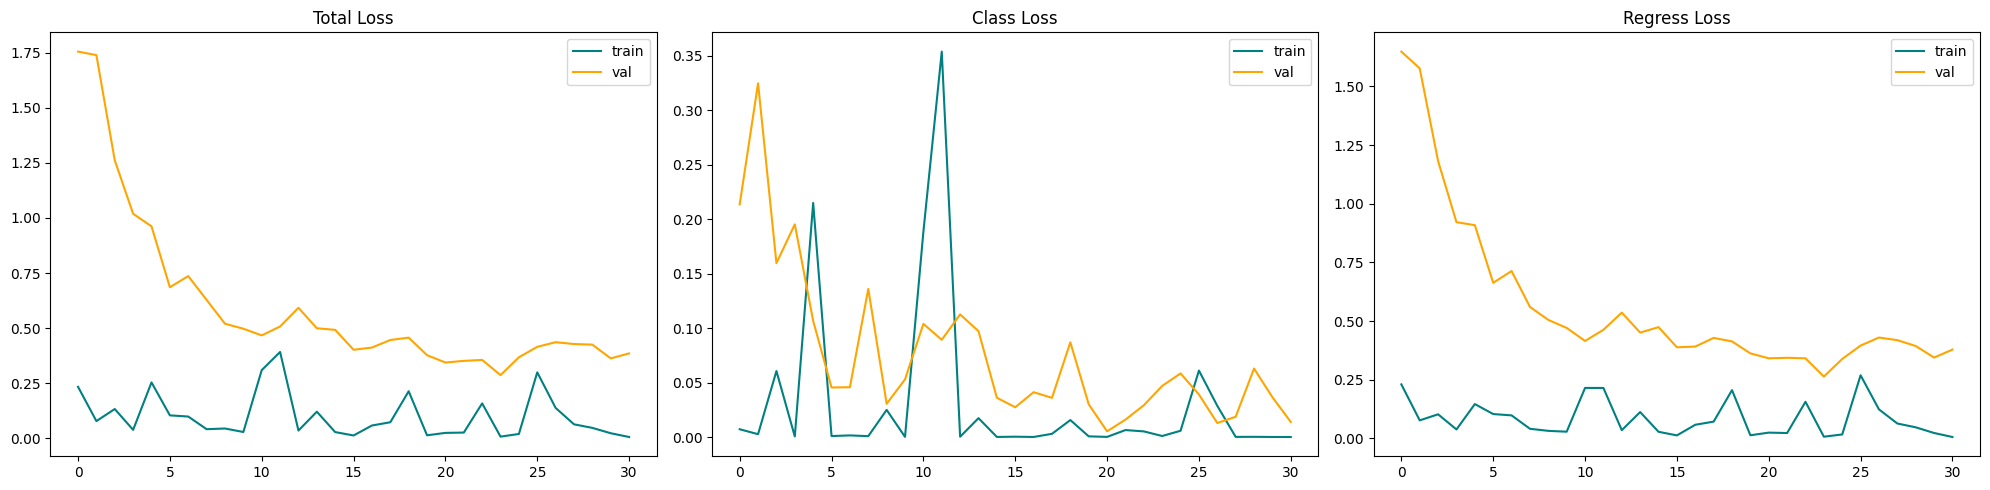

In [10]:
fig, ax = plt.subplots(ncols=3, figsize=(20,5))
for i, key in enumerate(['total_loss','class_loss','regress_loss']):
    ax[i].plot(hist.history[key],          color='teal',   label='train')
    ax[i].plot(hist.history[f'val_{key}'], color='orange', label='val')
    ax[i].set_title(key.replace('_',' ').title())
    ax[i].legend()
plt.tight_layout()
plt.show()

In [11]:
results = model.evaluate(test_ds.batch(BATCH), return_dict=True)
for k, v in results.items():
    print(f"  {k}: {v:.4f}")

375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - class_loss: 6.1565e-05 - regress_loss: 0.3604 - total_loss: 0.3604
  total_loss: 0.3604
  class_loss: 0.0001
  regress_loss: 0.3604


In [12]:
# Sanity check
test_files = tf.data.Dataset.list_files(
    os.path.join(WORK_DIR, 'aug_data', 'test', 'images', '*.jpg'),
    shuffle=False).take(5)

print("Sanity check:")
for path in test_files.as_numpy_iterator():
    img  = cv2.imread(path.decode())
    rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    inp  = np.expand_dims(tf.image.resize(rgb, (120,120)) / 255.0, 0)
    yhat = facetracker.predict(inp, verbose=0)
    conf = float(yhat[0][0][0])
    bbox = np.round(yhat[1][0], 3)
    print(f"  conf={conf:.4f}  bbox={bbox}  -> {'FACE' if conf>0.5 else 'no face'}")

Sanity check:
  conf=0.8935  bbox=[0.3   0.22  0.528 0.459]  -> FACE
  conf=0.9950  bbox=[0.256 0.31  0.472 0.594]  -> FACE
  conf=1.0000  bbox=[0.42  0.351 0.711 0.667]  -> FACE
  conf=0.9999  bbox=[0.233 0.333 0.518 0.67 ]  -> FACE
  conf=0.9923  bbox=[0.259 0.293 0.503 0.588]  -> FACE


In [13]:
facetracker.save(os.path.join(WORK_DIR, 'best_facetracker.h5'))
print("Saved: /kaggle/working/best_facetracker.h5")

Saved: /kaggle/working/best_facetracker.h5
